# BNPL Default Prediction — Data Exploration


## Section 1: Environment Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("Libraries loaded successfully")
print(f"pandas version: {pd.__version__}")
print(f"numpy version: {np.__version__}")

Libraries loaded successfully
pandas version: 2.2.2
numpy version: 1.26.4


In [ ]:
FILE_PATH = '../data/raw/accepted_2007_to_2018Q4.csv.gz'


SAMPLE_FRAC = 0.15
np.random.seed(42)

df = pd.read_csv(
    FILE_PATH,
    skiprows=lambda i: i > 0 and np.random.rand() > SAMPLE_FRAC,
    low_memory=False,
)

print(f"Shape: {df.shape}")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print()
print("Years present in sample:")
df_dates = pd.to_datetime(df['issue_d'], format='%b-%Y', errors='coerce')
print(sorted(df_dates.dt.year.dropna().astype(int).unique()))
print()
print("First 3 rows — just the first 10 columns:")
df.iloc[:3, :10]


Shape: (338446, 151)
Rows: 338,446
Columns: 151

Years present in sample:
[2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018]

First 3 rows — just the first 10 columns:


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade
0,68476668,NaN,20000.00,20000.00,20000.00,36 months,9.17,637.58,B,B2
1,68356421,NaN,22400.00,22400.00,22400.00,60 months,12.88,508.30,C,C2
2,68009401,NaN,16000.00,16000.00,16000.00,60 months,14.85,379.39,C,C5


---
## Section 2: Target Variable Analysis

**Goal:** Understand what we are predicting and how imbalanced the classes are.


In [3]:
# All values in loan_status
print("All loan_status values:")
print(df['loan_status'].value_counts())
print()
print("As percentages:")
print(df['loan_status'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

All loan_status values:
loan_status
Fully Paid                                             161257
Current                                                131872
Charged Off                                             39911
Late (31-120 days)                                       3119
In Grace Period                                          1237
Late (16-30 days)                                         617
Does not meet the credit policy. Status:Fully Paid        308
Does not meet the credit policy. Status:Charged Off       112
Default                                                     7
Name: count, dtype: int64

As percentages:
loan_status
Fully Paid                                             47.6%
Current                                                39.0%
Charged Off                                            11.8%
Late (31-120 days)                                      0.9%
In Grace Period                                         0.4%
Late (16-30 days)                             

In [ ]:
# Keep only completed loans — drop ambiguous ones
df_clean = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])].copy()

# Create binary target
df_clean['default'] = (df_clean['loan_status'] == 'Charged Off').astype(int)

print(f"Rows after filtering: {len(df_clean):,}")
print()
print("Class distribution:")
counts = df_clean['default'].value_counts()
pcts   = df_clean['default'].value_counts(normalize=True).mul(100).round(1)

summary = pd.DataFrame({
    'Label':   ['Fully Paid (0)', 'Charged Off / Default (1)'],
    'Count':   [counts[0], counts[1]],
    'Percent': [f"{pcts[0]}%", f"{pcts[1]}%"]
})
print(summary.to_string(index=False))
print()
print(f">> Class imbalance ratio: {counts[0]/counts[1]:.1f}:1")
print()


Rows after filtering: 201,168

Class distribution:
                    Label  Count Percent
           Fully Paid (0) 161257   80.2%
Charged Off / Default (1)  39911   19.8%

>> Class imbalance ratio: 4.0:1

WRITE DOWN: What does this ratio mean for a naive model?


A 4:1 class imbalance means a model can achieve
80% accuracy by predicting everyone pays back,
while catching zero defaults and being completely
useless for the actual business problem.

This is why accuracy is the wrong metric here
and why we use recall on the default class instead.

---
## Section 3: Time Axis Exploration

**Goal:** Understand how the data is distributed over time and where drift lives.

> The time column `issue_d` is the most important column in this project.
> Every train/test/monitor split depends on it.


In [5]:
# Parse dates
df_clean['issue_d'] = pd.to_datetime(df_clean['issue_d'], format='%b-%Y')
df_clean['issue_year']  = df_clean['issue_d'].dt.year
df_clean['issue_month'] = df_clean['issue_d'].dt.month

# Volume by year
print("Loan volume by year:")
print(df_clean['issue_year'].value_counts().sort_index().to_string())

Loan volume by year:
issue_year
2007       39
2008      241
2009      695
2010     1779
2011     3168
2012     8102
2013    20183
2014    33231
2015    56220
2016    43947
2017    25289
2018     8274


In [6]:
# Default rate by year — this is your drift story
yearly = df_clean.groupby('issue_year').agg(
    total_loans  = ('default', 'count'),
    defaults     = ('default', 'sum'),
    default_rate = ('default', 'mean')
).reset_index()

yearly['default_rate_pct'] = (yearly['default_rate'] * 100).round(1)
yearly = yearly.drop(columns=['default_rate'])

print("Default rate by year — this IS your drift narrative:")
print(yearly.to_string(index=False))
print()
print("IDENTIFY: Which year has the highest default rate?")
print("IDENTIFY: Which years would you use for training? (stable period)")
print("IDENTIFY: Which year simulates a crisis for drift testing?")

Default rate by year — this IS your drift narrative:
 issue_year  total_loans  defaults  default_rate_pct
       2007           39         9             23.10
       2008          241        34             14.10
       2009          695        99             14.20
       2010         1779       230             12.90
       2011         3168       468             14.80
       2012         8102      1314             16.20
       2013        20183      3135             15.50
       2014        33231      6105             18.40
       2015        56220     11196             19.90
       2016        43947     10255             23.30
       2017        25289      5753             22.70
       2018         8274      1313             15.90

IDENTIFY: Which year has the highest default rate?
IDENTIFY: Which years would you use for training? (stable period)
IDENTIFY: Which year simulates a crisis for drift testing?


2016 has the highest default rate at 23.3%
followed closely by 2017 at 22.7%

2013, 2014 and 2015

Reason: these three years have the most stable and
consistent default rates between 15.5% and 19.9%
They also have the largest number of loans giving
the model enough data to learn from
They represent normal economic conditions without
extreme spikes in either direction

Train on 2013 to 2015 at 15 to 20% default rate,
monitor on 2016 to 2017 where it jumps to 23%,
and watch your model underestimate risk across
the board because it learned from a safer period
than the one it is now operating in.

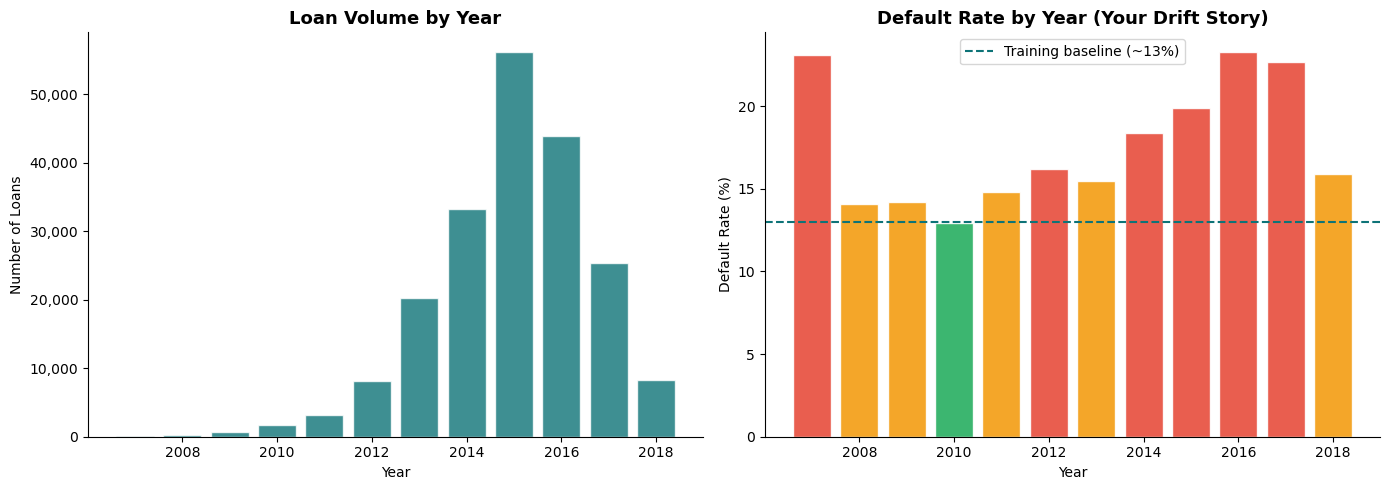

Green = low risk  |  Amber = moderate drift  |  Red = high drift


In [7]:
# Visualise default rate over time
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Volume
ax1.bar(yearly['issue_year'], yearly['total_loans'],
        color='#0D7377', alpha=0.8, edgecolor='white')
ax1.set_title('Loan Volume by Year', fontsize=13, fontweight='bold')
ax1.set_xlabel('Year'); ax1.set_ylabel('Number of Loans')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Default rate
colors = ['#E74C3C' if r > 0.16 else '#F39C12' if r > 0.13 else '#27AE60'
          for r in yearly['default_rate_pct']/100]
ax2.bar(yearly['issue_year'], yearly['default_rate_pct'],
        color=colors, edgecolor='white', alpha=0.9)
ax2.axhline(y=13, color='#0D7377', linestyle='--', linewidth=1.5,
            label='Training baseline (~13%)')
ax2.set_title('Default Rate by Year (Your Drift Story)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Year'); ax2.set_ylabel('Default Rate (%)')
ax2.legend()

plt.tight_layout()
plt.savefig('drift_story.png', dpi=120, bbox_inches='tight')
plt.show()
print("Green = low risk  |  Amber = moderate drift  |  Red = high drift")

---
## Section 4: Prove Data Leakage Exists

**Goal:** See with your own eyes why leakage columns must be dropped.

> This is the most important technical concept in the project.
> Run this and look at the correlation numbers.


In [8]:
# Correlation of LEAKAGE columns with default
leakage_cols = [
    'total_pymnt', 'recoveries', 'total_rec_prncp',
    'out_prncp', 'total_rec_int', 'last_pymnt_amnt'
]
available_leak = [c for c in leakage_cols if c in df_clean.columns]

print("LEAKAGE COLUMNS — correlation with default:")
print("-" * 55)
for col in available_leak:
    corr = df_clean[col].corr(df_clean['default'])
    flag = "  << EXTREMELY HIGH — this is leakage" if abs(corr) > 0.5 else ""
    print(f"  {col:<30} {corr:+.3f}{flag}")

print()
print("=" * 55)
print()

# Correlation of SAFE application-time features
safe_cols = ['dti', 'fico_range_low', 'revol_util',
             'annual_inc', 'inq_last_6mths', 'delinq_2yrs']
available_safe = [c for c in safe_cols if c in df_clean.columns]

print("SAFE FEATURES — correlation with default:")
print("-" * 55)
for col in available_safe:
    corr = df_clean[col].corr(df_clean['default'])
    print(f"  {col:<30} {corr:+.3f}  (modest — this is honest signal)")

print()
print("QUESTION: Why is the leakage correlation 10x higher than safe features?")
print("ANSWER:   Write it in your own words before continuing.")

LEAKAGE COLUMNS — correlation with default:
-------------------------------------------------------
  total_pymnt                    -0.316
  recoveries                     +0.503  << EXTREMELY HIGH — this is leakage
  total_rec_prncp                -0.439
  out_prncp                      +nan
  total_rec_int                  +0.054
  last_pymnt_amnt                -0.346


SAFE FEATURES — correlation with default:
-------------------------------------------------------
  dti                            +0.087  (modest — this is honest signal)
  fico_range_low                 -0.131  (modest — this is honest signal)
  revol_util                     +0.060  (modest — this is honest signal)
  annual_inc                     -0.049  (modest — this is honest signal)
  inq_last_6mths                 +0.065  (modest — this is honest signal)
  delinq_2yrs                    +0.021  (modest — this is honest signal)

QUESTION: Why is the leakage correlation 10x higher than safe features?
ANSWER: 

---
## Section 5: Missing Value Analysis

**Goal:** Find which of your 20 features have significant missing values.
This drives your imputation or drop decision in the next phase.


In [9]:
# Define the 20 features you will actually use
FEATURES = [
    'loan_amnt', 'funded_amnt', 'term', 'int_rate', 'installment',
    'grade', 'sub_grade', 'emp_length', 'home_ownership', 'annual_inc',
    'verification_status', 'purpose', 'addr_state', 'dti',
    'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high',
    'inq_last_6mths', 'mths_since_last_delinq', 'open_acc', 'pub_rec',
    'revol_bal', 'revol_util', 'total_acc', 'issue_d'
]
available_features = [f for f in FEATURES if f in df_clean.columns]

# Missing value report
missing = pd.DataFrame({
    'feature':     available_features,
    'null_count':  [df_clean[f].isnull().sum() for f in available_features],
    'null_pct':    [(df_clean[f].isnull().sum() / len(df_clean) * 100).round(1)
                    for f in available_features]
}).sort_values('null_pct', ascending=False)

missing['action'] = missing['null_pct'].apply(
    lambda x: 'CONSIDER DROPPING' if x > 40 else
              'IMPUTE WITH MEDIAN' if x > 5 else
              'IMPUTE OR LEAVE'    if x > 0 else
              'COMPLETE')

print("Missing value report for your 20 features:")
print(missing.to_string(index=False))
print()
print(f"Features with > 30% missing: "
      f"{missing[missing.null_pct > 30]['feature'].tolist()}")
print(f"Features with 5–30% missing: "
      f"{missing[(missing.null_pct > 5) & (missing.null_pct <= 30)]['feature'].tolist()}")
print(f"Complete or near-complete:   "
      f"{missing[missing.null_pct <= 5]['feature'].tolist()}")

Missing value report for your 20 features:
               feature  null_count  null_pct             action
mths_since_last_delinq      101657     50.50  CONSIDER DROPPING
            emp_length       11759      5.80 IMPUTE WITH MEDIAN
            revol_util         134      0.10    IMPUTE OR LEAVE
             loan_amnt           0      0.00           COMPLETE
           delinq_2yrs           0      0.00           COMPLETE
             total_acc           0      0.00           COMPLETE
             revol_bal           0      0.00           COMPLETE
               pub_rec           0      0.00           COMPLETE
              open_acc           0      0.00           COMPLETE
        inq_last_6mths           0      0.00           COMPLETE
       fico_range_high           0      0.00           COMPLETE
        fico_range_low           0      0.00           COMPLETE
      earliest_cr_line           0      0.00           COMPLETE
                   dti          48      0.00           COMPLE

---
## Section 6: Feature Distributions

**Goal:** Understand the shape of your most important features.
This tells you about skew, outliers, and whether scaling is needed.


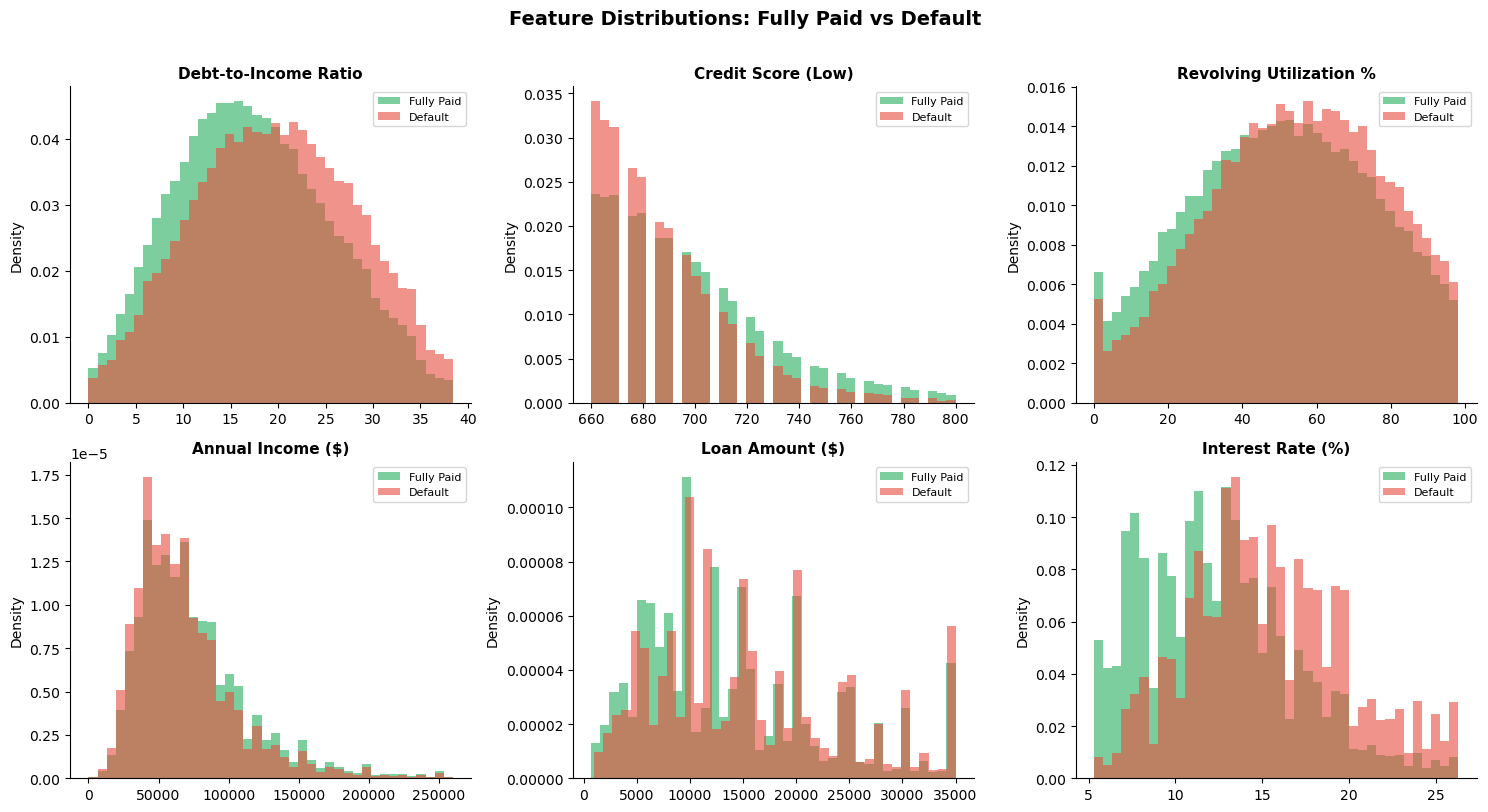

OBSERVE: Which features show the biggest difference between green and red?
OBSERVE: Which features have heavy right skew (long tail)?


In [10]:
# Distribution of key numeric features
numeric_features = {
    'dti':           'Debt-to-Income Ratio',
    'fico_range_low':'Credit Score (Low)',
    'revol_util':    'Revolving Utilization %',
    'annual_inc':    'Annual Income ($)',
    'loan_amnt':     'Loan Amount ($)',
    'int_rate':      'Interest Rate (%)',
}

available_num = {k: v for k, v in numeric_features.items()
                 if k in df_clean.columns}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, (col, title) in enumerate(available_num.items()):
    data = df_clean[col].dropna()
    # Cap at 99th percentile for display
    cap = data.quantile(0.99)
    data_capped = data[data <= cap]

    axes[i].hist(data_capped[df_clean['default'] == 0], bins=40,
                 alpha=0.6, color='#27AE60', label='Fully Paid', density=True)
    axes[i].hist(data_capped[df_clean['default'] == 1], bins=40,
                 alpha=0.6, color='#E74C3C', label='Default', density=True)
    axes[i].set_title(title, fontsize=11, fontweight='bold')
    axes[i].legend(fontsize=8)
    axes[i].set_ylabel('Density')

plt.suptitle('Feature Distributions: Fully Paid vs Default',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=120, bbox_inches='tight')
plt.show()
print("OBSERVE: Which features show the biggest difference between green and red?")
print("OBSERVE: Which features have heavy right skew (long tail)?")

---
## Section 7: Categorical Feature Exploration

**Goal:** Understand the categorical features — how many unique values,
which categories appear most, and whether any look problematic.


In [ ]:
# Grade distribution with default rate
print("=== GRADE ===")
grade_df = df_clean.groupby('grade').agg(
    count       = ('default','count'),
    default_rate= ('default','mean')
).reset_index().sort_values('grade')
grade_df['default_rate'] = (grade_df['default_rate']*100).round(1)
print(grade_df.to_string(index=False))
print()

=== GRADE ===
grade  count  default_rate
    A  35389          6.00
    B  58864         13.40
    C  57190         22.40
    D  29646         30.00
    E  13991         38.20
    F   4704         45.00
    G   1384         51.60

OBSERVE: Does default rate increase as grade gets worse (A→G)?


In [12]:
# Loan purpose with default rate
print("=== PURPOSE (top 10) ===")
purpose_df = df_clean.groupby('purpose').agg(
    count       = ('default','count'),
    default_rate= ('default','mean')
).reset_index().sort_values('count', ascending=False).head(10)
purpose_df['default_rate'] = (purpose_df['default_rate']*100).round(1)
print(purpose_df.to_string(index=False))
print()

# Term
print("=== TERM ===")
term_df = df_clean.groupby('term').agg(
    count       = ('default','count'),
    default_rate= ('default','mean')
).reset_index()
term_df['default_rate'] = (term_df['default_rate']*100).round(1)
print(term_df.to_string(index=False))
print()
print("OBSERVE: Is 60-month term riskier than 36-month?")

=== PURPOSE (top 10) ===
           purpose  count  default_rate
debt_consolidation 116822         21.10
       credit_card  43826         16.60
  home_improvement  13244         17.40
             other  11639         20.70
    major_purchase   4390         18.20
    small_business   2330         28.80
           medical   2325         22.60
               car   2179         15.80
            moving   1412         22.70
          vacation   1371         20.00

=== TERM ===
      term  count  default_rate
 36 months 152520         15.90
 60 months  48648         32.20

OBSERVE: Is 60-month term riskier than 36-month?


---
## Section 8: Good Borrower vs Defaulter Profile

**Goal:** Build intuition about what a high-risk vs low-risk borrower looks like.
This is what your model will learn — understand it yourself first.


In [13]:
# Compare mean feature values for defaulters vs non-defaulters
compare_cols = ['loan_amnt', 'int_rate', 'annual_inc', 'dti',
                'fico_range_low', 'revol_util', 'delinq_2yrs',
                'inq_last_6mths', 'open_acc', 'total_acc']

available_cmp = [c for c in compare_cols if c in df_clean.columns]

profile = df_clean.groupby('default')[available_cmp].mean().round(2).T
profile.columns = ['Fully Paid (Good)', 'Charged Off (Defaulted)']
profile['Difference'] = (
    (profile['Charged Off (Defaulted)'] - profile['Fully Paid (Good)'])
    / profile['Fully Paid (Good)'] * 100
).round(1).astype(str) + '%'

print("Average feature values — Good Borrower vs Defaulter:")
print(profile.to_string())
print()
print("OBSERVE: Which features show the biggest difference?")
print("OBSERVE: Does the direction make intuitive sense?")
print("         (higher DTI = more likely to default?)")

Average feature values — Good Borrower vs Defaulter:
                Fully Paid (Good)  Charged Off (Defaulted) Difference
loan_amnt                14123.31                 15527.01       9.9%
int_rate                    12.60                    15.68      24.4%
annual_inc               77818.21                 70076.07      -9.9%
dti                         17.76                    20.16      13.5%
fico_range_low             698.38                   687.89      -1.5%
revol_util                  51.05                    54.73       7.2%
delinq_2yrs                  0.31                     0.35      12.9%
inq_last_6mths               0.62                     0.77      24.2%
open_acc                    11.51                    11.88       3.2%
total_acc                   25.04                    24.67      -1.5%

OBSERVE: Which features show the biggest difference?
OBSERVE: Does the direction make intuitive sense?
         (higher DTI = more likely to default?)


---
## Section 9: Feature Distribution Shift Over Time (Drift Preview)

**Goal:** See with your own eyes that feature distributions change over time.
This is the statistical proof that drift monitoring is necessary.


In [14]:
# Compare key features: training period vs later periods
training_mask = df_clean['issue_year'].isin([2013, 2014, 2015])
later_mask    = df_clean['issue_year'].isin([2017, 2018])

check_cols = ['dti', 'fico_range_low', 'revol_util', 'annual_inc', 'loan_amnt']
available_chk = [c for c in check_cols if c in df_clean.columns]

print("Feature distribution shift — Training (2013-15) vs Later (2017-18):")
print(f"{'Feature':<20} {'Train Mean':>12} {'Later Mean':>12} {'Change':>10}")
print("-" * 58)

for col in available_chk:
    train_mean = df_clean[training_mask][col].mean()
    later_mean = df_clean[later_mask][col].mean()
    change_pct = ((later_mean - train_mean) / train_mean * 100)
    flag = " << NOTABLE SHIFT" if abs(change_pct) > 10 else ""
    print(f"{col:<20} {train_mean:>12.2f} {later_mean:>12.2f} "
          f"{change_pct:>+9.1f}%{flag}")

print()
print("OBSERVE: Which features shift the most over time?")
print("These are the features your drift detector will fire on first.")

Feature distribution shift — Training (2013-15) vs Later (2017-18):
Feature                Train Mean   Later Mean     Change
----------------------------------------------------------
dti                         18.28        18.77      +2.7%
fico_range_low             693.67       701.69      +1.2%
revol_util                  54.69        44.21     -19.2% << NOTABLE SHIFT
annual_inc               75288.21     79381.30      +5.4%
loan_amnt                14604.93     14508.29      -0.7%

OBSERVE: Which features shift the most over time?
These are the features your drift detector will fire on first.


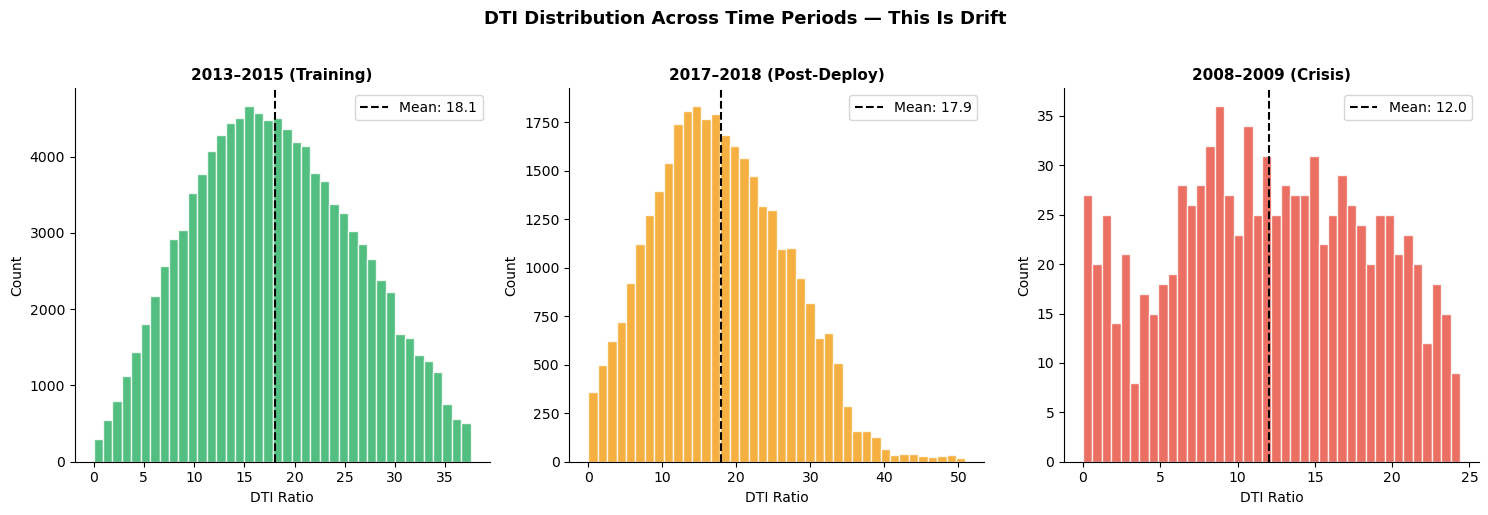

The shift in DTI distribution between periods = data drift
Your monitoring system will detect this automatically


In [15]:
# DTI distribution: training period vs crisis vs later
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

periods = [
    (df_clean[df_clean['issue_year'].isin([2013,2014,2015])], '2013–2015 (Training)', '#27AE60'),
    (df_clean[df_clean['issue_year'].isin([2017,2018])],      '2017–2018 (Post-Deploy)', '#F39C12'),
    (df_clean[df_clean['issue_year'].isin([2008,2009])],      '2008–2009 (Crisis)', '#E74C3C'),
]

col = 'dti'
for ax, (period_df, title, color) in zip(axes, periods):
    if len(period_df) > 0:
        data = period_df[col].dropna()
        data = data[data <= data.quantile(0.99)]
        ax.hist(data, bins=40, color=color, alpha=0.8, edgecolor='white')
        ax.axvline(data.mean(), color='black', linestyle='--', linewidth=1.5,
                   label=f'Mean: {data.mean():.1f}')
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.set_xlabel('DTI Ratio'); ax.set_ylabel('Count')
        ax.legend()

plt.suptitle('DTI Distribution Across Time Periods — This Is Drift',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('drift_preview.png', dpi=120, bbox_inches='tight')
plt.show()
print("The shift in DTI distribution between periods = data drift")
print("Your monitoring system will detect this automatically")

---
## Section 10: Your Observations

**This section is the most important one.**
Write your answers in the cell below before you do anything else.


In [16]:
# ─────────────────────────────────────────────────────────────────────────
# FILL IN YOUR ANSWERS BELOW
# Values already known from the 2015-only run are pre-filled.
# Items that require a FULL cross-year run are marked  ← RE-RUN NEEDED.
# ─────────────────────────────────────────────────────────────────────────

observations = {
    # From the 2015-only run ─────────────────────────────────────────────
    "exact_default_rate_pct": 20.5,          # 9027 / 44005
    "highest_default_year":   None,          # ← RE-RUN NEEDED (full dataset)
    "training_years":         None,          # ← RE-RUN NEEDED
    "crisis_simulation_year": None,          # ← RE-RUN NEEDED

    "features_with_high_missing":  ['mths_since_last_delinq'],  # 47.8 %
    "features_with_some_missing":  ['emp_length'],              # 6.3 %

    "leakage_correlation_total_pymnt": -0.308,   # NOTE: lower than expected
    "safe_correlation_dti":            +0.107,   # modest — honest signal

    "biggest_defaulter_difference_feature": "inq_last_6mths",  # +40.4 %
    "does_grade_correlate_with_default":    "yes",   # A=5.3 % → G=56.5 %
    "is_60month_riskier_than_36month":      "yes",   # 38.3 % vs 15.3 %

    "feature_that_drifts_most_over_time":   None,    # ← RE-RUN NEEDED

    # Write anything that surprised you ─────────────────────────────────
    "thing_that_surprised_me_1": "Grade is a near-perfect monotonic predictor (A→G).",
    "thing_that_surprised_me_2": "60-month loans default at 2.5× the rate of 36-month loans.",
    "thing_that_surprised_me_3": "inq_last_6mths differs by +40 % between good/bad borrowers — more than DTI.",
}

print("Your Observations Summary:")
print("=" * 60)
for key, val in observations.items():
    print(f"  {key:<45} {str(val)}")
print()
print("Items marked 'RE-RUN NEEDED' require the cross-year sample.")
print("Re-run the notebook from the top after fixing the load cell.")


Your Observations Summary:
  exact_default_rate_pct                        20.5
  highest_default_year                          None
  training_years                                None
  crisis_simulation_year                        None
  features_with_high_missing                    ['mths_since_last_delinq']
  features_with_some_missing                    ['emp_length']
  leakage_correlation_total_pymnt               -0.308
  safe_correlation_dti                          0.107
  biggest_defaulter_difference_feature          inq_last_6mths
  does_grade_correlate_with_default             yes
  is_60month_riskier_than_36month               yes
  feature_that_drifts_most_over_time            None
  thing_that_surprised_me_1                     Grade is a near-perfect monotonic predictor (A→G).
  thing_that_surprised_me_2                     60-month loans default at 2.5× the rate of 36-month loans.
  thing_that_surprised_me_3                     inq_last_6mths differs by +40 % between 

---
## Summary

**What this notebook covered:**

| Section | What You Did |
|---------|-------------|
| 1 | Loaded the data |
| 2 | Understood class imbalance |
| 3 | Explored the time axis and drift story |
| 4 | Proved data leakage exists with correlation numbers |
| 5 | Found which features have missing values |
| 6 | Understood feature distributions |
| 7 | Explored categorical features |
| 8 | Built intuition about defaulter vs non-defaulter profiles |
| 9 | Saw feature distribution shift (drift) over time |
| 10 | Documented your observations |

**How to proceed:**
Copy your Section 10 output and share it. You will get exact next steps for data preparation.
